<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/VentValveEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set()
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
sklearn.__version__

'1.6.1'

In [2]:
from google.colab import files
import pandas as pd


uploaded = files.upload()

df_raw = pd.read_csv('valve_3 (1).csv', sep='\t')   # <-- plik oddzielany tabulatorami
print("Dane wczytane poprawnie!\n")
print(df_raw.head())

Saving valve_3.csv to valve_3 (3).csv
Dane wczytane poprawnie!

                 Nazwa  129A00041
0  2024-05-18 06:00:00        0.0
1  2024-05-18 06:01:00        0.0
2  2024-05-18 06:02:00        0.0
3  2024-05-18 06:03:00        0.0
4  2024-05-18 06:04:00        0.0


In [3]:
# 1. Utworzenie kopii danych
df = df_raw.copy()

# 2. Zmiana nazw kolumn
df = df.rename(columns={
    'Nazwa': 'TIME',
    '129A00041': 'STEAM_FLOW'
})
# 3. Podgląd pierwszych wierszy
print(df.head())

                  TIME  STEAM_FLOW
0  2024-05-18 06:00:00         0.0
1  2024-05-18 06:01:00         0.0
2  2024-05-18 06:02:00         0.0
3  2024-05-18 06:03:00         0.0
4  2024-05-18 06:04:00         0.0


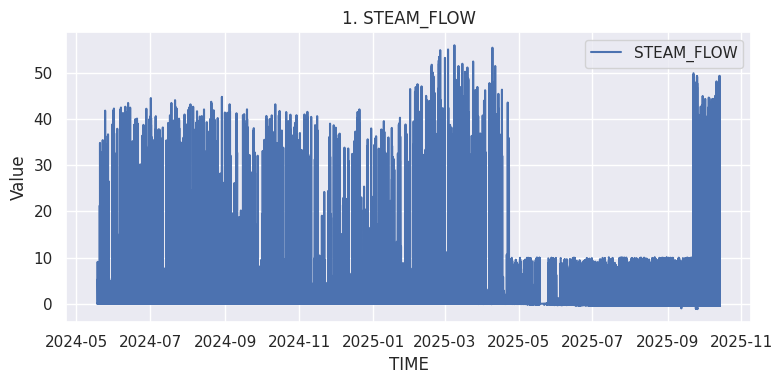

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Wczytaj dane (jeśli już masz df, pomiń ten krok) ---
# df = pd.read_csv('twoj_plik.csv')

# --- Konwersja czasu ---
df['TIME'] = pd.to_datetime(df['TIME'])

# --- Zestawy danych do wykresów ---
plots = [
    (['STEAM_FLOW'], '1. STEAM_FLOW')
]

# --- Tworzenie wykresów ---
for cols, title in plots:
    plt.figure(figsize=(8, 4))
    for c in cols:
        plt.plot(df['TIME'], df[c], label=c)
    plt.title(title)
    plt.xlabel('TIME')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Suma dzienna i miesięczna

/tmp/ipython-input-3708365602.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


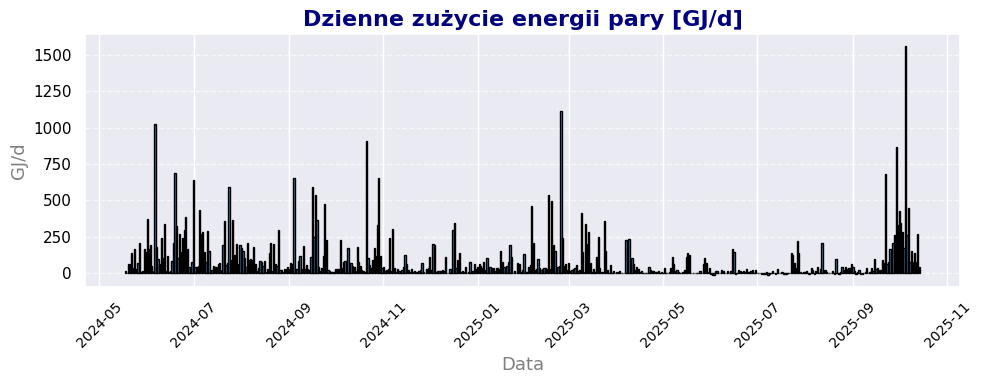

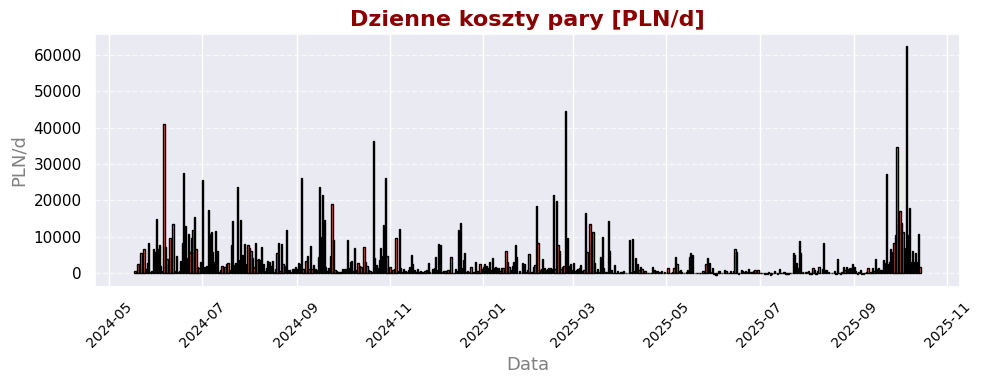

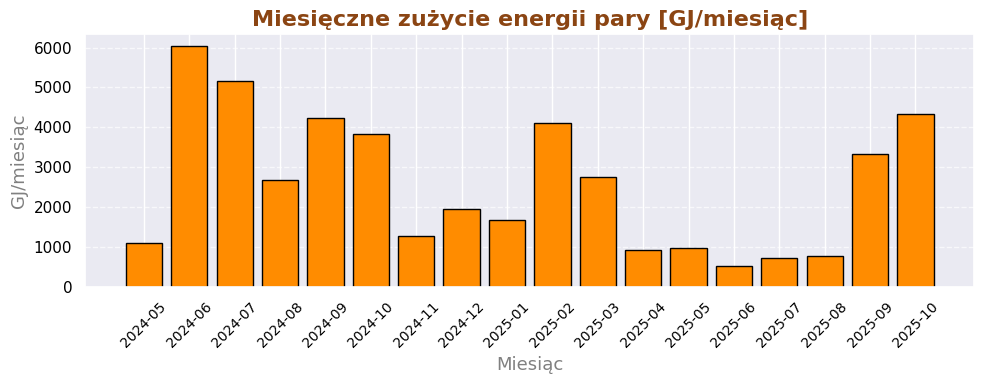

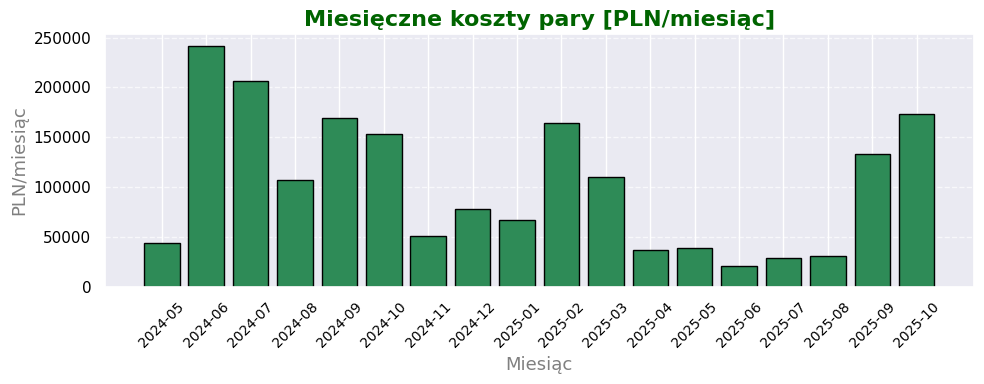

=== df_daily ===
        TIME  DAILY_STEAM_t  DAILY_Q_GJ  DAILY_COST_PLN
0 2024-05-18       3.880667   10.671833      426.873333
1 2024-05-19       1.070667    2.944333      117.773333
2 2024-05-20      21.647667   59.531083     2381.243333
3 2024-05-21      23.632333   64.988917     2599.556667
4 2024-05-22      49.290333  135.548417     5421.936667

=== df_monthly ===
        TIME  MONTHLY_STEAM_t  MONTHLY_Q_GJ  MONTHLY_COST_PLN
0 2024-05-31       399.895167   1099.711708      43988.468333
1 2024-06-30      2192.920167   6030.530458     241221.218333
2 2024-07-31      1874.885167   5155.934208     206237.368333
3 2024-08-31       969.677167   2666.612208     106664.488333
4 2024-09-30      1541.287833   4238.541542     169541.661667


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Upewnijmy się, że TIME to datetime i jest posortowane ---
df['TIME'] = pd.to_datetime(df['TIME'], errors='coerce')
df = df.sort_values('TIME')

# --- 1. Oblicz krok czasowy między próbkami [h] dla każdej próbki ---
# diff() daje ile czasu minęło od poprzedniego punktu
df['dt_h'] = df['TIME'].diff().dt.total_seconds() / 3600.0

# Pierwszy wiersz nie ma poprzednika -> dt_h = NaN. Uzupełnij go medianą kroku.
median_dt_h = df['dt_h'].median()
df['dt_h'] = df['dt_h'].fillna(median_dt_h)

# --- 2. Policz ile ton pary przepłynęło w każdym odcinku czasu ---
# STEAM_FLOW [t/h] * dt_h [h] = masa [t] w tym interwale
df['STEAM_MASS_t'] = df['STEAM_FLOW'] * df['dt_h']  # [t w danym kroku]

# --- 3. Policz energię dla każdego kroku (GJ w kroku)
H_GJ_per_ton = 2.75        # przyjęta entalpia [GJ / t]
df['Q_GJ'] = df['STEAM_MASS_t'] * H_GJ_per_ton   # energia w tym kroku czasu [GJ]

# --- 4. Policz koszt dla każdego kroku
COST_PER_GJ = 40.0         # PLN / GJ
df['COST_PLN'] = df['Q_GJ'] * COST_PER_GJ        # koszt w tym kroku [PLN]

# =========================
#   SUMY DZIENNE
# =========================
df_daily = (
    df.set_index('TIME')
      .resample('D')
      .agg({
          'STEAM_MASS_t': 'sum',   # t/d
          'Q_GJ': 'sum',           # GJ/d
          'COST_PLN': 'sum'        # PLN/d
      })
      .reset_index()
      .rename(columns={
          'STEAM_MASS_t': 'DAILY_STEAM_t',
          'Q_GJ': 'DAILY_Q_GJ',
          'COST_PLN': 'DAILY_COST_PLN'
      })
)

# =========================
#   SUMY MIESIĘCZNE
# =========================
df_monthly = (
    df.set_index('TIME')
      .resample('M')
      .agg({
          'STEAM_MASS_t': 'sum',   # t/miesiąc
          'Q_GJ': 'sum',           # GJ/miesiąc
          'COST_PLN': 'sum'        # PLN/miesiąc
      })
      .reset_index()
      .rename(columns={
          'STEAM_MASS_t': 'MONTHLY_STEAM_t',
          'Q_GJ': 'MONTHLY_Q_GJ',
          'COST_PLN': 'MONTHLY_COST_PLN'
      })
)

# =========================
#   WYKRESY
# =========================

# DZIENNE GJ/d
plt.figure(figsize=(10,4))
plt.bar(df_daily['TIME'], df_daily['DAILY_Q_GJ'], color='steelblue', edgecolor='black')
plt.title('Dzienne zużycie energii pary [GJ/d]', fontsize=16, fontweight='bold', color='navy')
plt.xlabel('Data', fontsize=13, color='gray')
plt.ylabel('GJ/d', fontsize=13, color='gray')
plt.xticks(fontsize=10, rotation=45, color='black')
plt.yticks(fontsize=11, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# DZIENNE KOSZTY PLN/d
plt.figure(figsize=(10,4))
plt.bar(df_daily['TIME'], df_daily['DAILY_COST_PLN'], color='tomato', edgecolor='black')
plt.title('Dzienne koszty pary [PLN/d]', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Data', fontsize=13, color='gray')
plt.ylabel('PLN/d', fontsize=13, color='gray')
plt.xticks(fontsize=10, rotation=45, color='black')
plt.yticks(fontsize=11, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# MIESIĘCZNE GJ/miesiąc
plt.figure(figsize=(10,4))
plt.bar(df_monthly['TIME'].dt.strftime('%Y-%m'),
        df_monthly['MONTHLY_Q_GJ'],
        color='darkorange', edgecolor='black')
plt.title('Miesięczne zużycie energii pary [GJ/miesiąc]', fontsize=16, fontweight='bold', color='saddlebrown')
plt.xlabel('Miesiąc', fontsize=13, color='gray')
plt.ylabel('GJ/miesiąc', fontsize=13, color='gray')
plt.xticks(fontsize=10, rotation=45, color='black')
plt.yticks(fontsize=11, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# MIESIĘCZNE KOSZTY PLN/miesiąc
plt.figure(figsize=(10,4))
plt.bar(df_monthly['TIME'].dt.strftime('%Y-%m'),
        df_monthly['MONTHLY_COST_PLN'],
        color='seagreen', edgecolor='black')
plt.title('Miesięczne koszty pary [PLN/miesiąc]', fontsize=16, fontweight='bold', color='darkgreen')
plt.xlabel('Miesiąc', fontsize=13, color='gray')
plt.ylabel('PLN/miesiąc', fontsize=13, color='gray')
plt.xticks(fontsize=10, rotation=45, color='black')
plt.yticks(fontsize=11, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# podgląd tabel
print("=== df_daily ===")
print(df_daily.head())

print("\n=== df_monthly ===")
print(df_monthly.head())


Załóż teraz